In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# NLP libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans as TextKMeans

In [2]:
# Load dataset
df = pd.read_csv("iris-data.csv")

# Display first rows
df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Dataset shape
print(df.shape)

# Column names
print(df.columns)

# Missing values
df.isnull().sum()

# Data information
df.info()

(150, 5)
Index(['sepal length', 'sepal width', 'petal length', 'petal width', 'class'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  150 non-null    float64
 1   sepal width   150 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
 4   class         150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


In [4]:
# Select numeric features
X = df.select_dtypes(include=[np.number])

X.head()

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.90068117,  1.03205722, -1.3412724 , -1.31297673],
       [-1.14301691, -0.1249576 , -1.3412724 , -1.31297673],
       [-1.38535265,  0.33784833, -1.39813811, -1.31297673],
       [-1.50652052,  0.10644536, -1.2844067 , -1.31297673],
       [-1.02184904,  1.26346019, -1.3412724 , -1.31297673]])

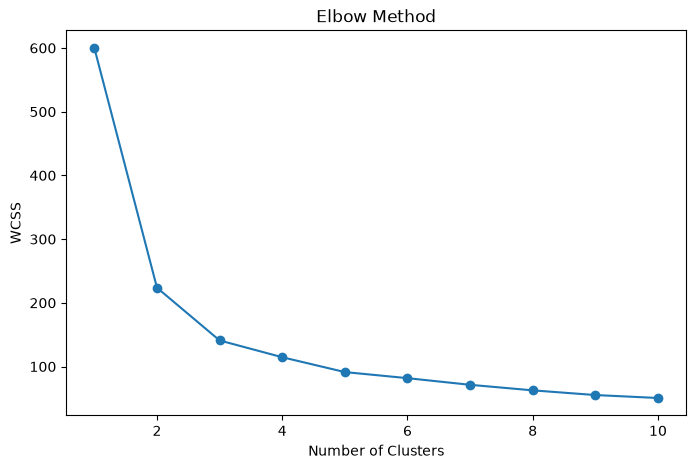

In [6]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [7]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

,sepal length,sepal width,petal length,petal width,class,Cluster
0,5.1,3.5,1.4,0.2,Iris-setosa,1
1,4.9,3.0,1.4,0.2,Iris-setosa,1
2,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5.0,3.6,1.4,0.2,Iris-setosa,1


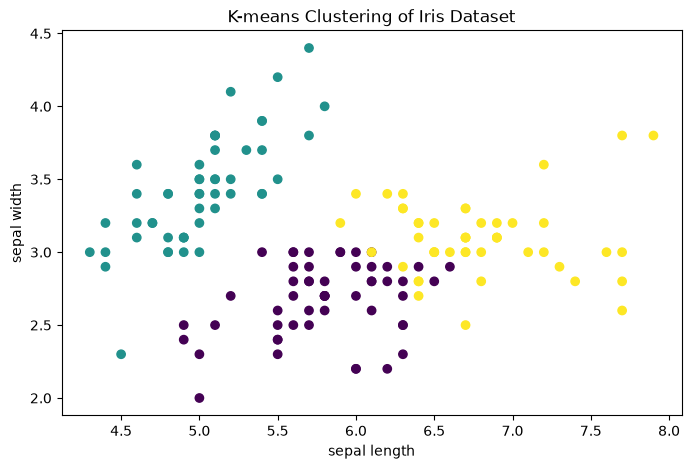

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("K-means Clustering of Iris Dataset")

plt.show()

In [9]:
# Check if text column exists
if "text" in df.columns:

    documents = df["text"].astype(str)

    # Convert text into numerical vectors
    vectorizer = TfidfVectorizer(
        stop_words="english"
    )

    text_features = vectorizer.fit_transform(documents)


    # K-means on text data
    text_kmeans = TextKMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
    )

    text_clusters = text_kmeans.fit_predict(text_features)


    df["Text_Cluster"] = text_clusters

    df.head()